<a href="https://colab.research.google.com/github/cjlantigua-hue/gmp-audit-risk-dashboard/blob/main/notebook/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Pareto, Trend, Recurrence and CAPA Analysis
**Project:** GMP Audit Findings Risk Dashboard · **Company:** Meridian Pharma (fictional)

This notebook answers the questions QA leadership would ask before an inspection:

| Section | Question |
|---|---|
| 2. Pareto | Which few problems make up most of our findings, and most of our **risk**? |
| 3. Trends | Which sites are getting better or worse? Are we closing CAPAs on time? |
| 4. Recurrence | Which problems keep coming back, and does a failed CAPA predict a repeat? |
| 5. Site profile | Which site needs the most attention, and why? |
| 6. CAPA aging | How old are the CAPAs that are still open? |
| 7. Key insights | Plain-language findings for the dashboard and README |

The insights in Section 7 are **written by the code from the data**, so they always match the numbers.
Charts are saved to `figures/` in Drive so you can add them to the README.

**How to run:** run `01_generate_data` and `02_risk_scoring` first, then `Runtime → Run all`.

## 1. Setup and load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = '/content/drive/MyDrive/gmp-audit-risk-dashboard'
except ImportError:
    PROJECT = './gmp-audit-risk-dashboard'

FIG_DIR = f'{PROJECT}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

SNAPSHOT = pd.Timestamp('2026-09-30')
START    = pd.Timestamp('2023-10-01')

df = pd.read_csv(f'{PROJECT}/data/processed/findings_scored.csv',
                 parse_dates=['audit_date', 'open_date', 'due_date', 'close_date'])
audits = pd.read_csv(f'{PROJECT}/data/raw/audits.csv', parse_dates=['audit_date'])
sites  = pd.read_csv(f'{PROJECT}/data/raw/sites.csv')
audits = audits.merge(sites[['site_id', 'site_name']], on='site_id')

closed = df['status'] == 'Closed'
active = ~closed
print(f'{len(df)} findings from {len(audits)} audits at {df.site_name.nunique()} sites | '
      f'{active.sum()} CAPAs still open on {SNAPSHOT.date()}')

# --- Chart style (shared by every chart) ---
GRAY, INK, MUTED = '#b4b2a9', '#0b0b0b', '#52514e'
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
TIER_COLORS = {'High': '#d03b3b', 'Medium': '#fab219', 'Low': '#0ca30c'}
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': GRAY,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True, 'grid.color': '#ecebe6',
                     'grid.linewidth': 0.8, 'axes.axisbelow': True, 'legend.frameon': False})

def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight')

Mounted at /content/drive
1365 findings from 163 audits at 5 sites | 73 CAPAs still open on 2026-09-30


## 2. Pareto analysis
The classic Pareto chart counts findings. But a dashboard about **risk** should also ask which categories
carry the most risk score. If the two rankings differ, counting alone would point leadership at the wrong problem.

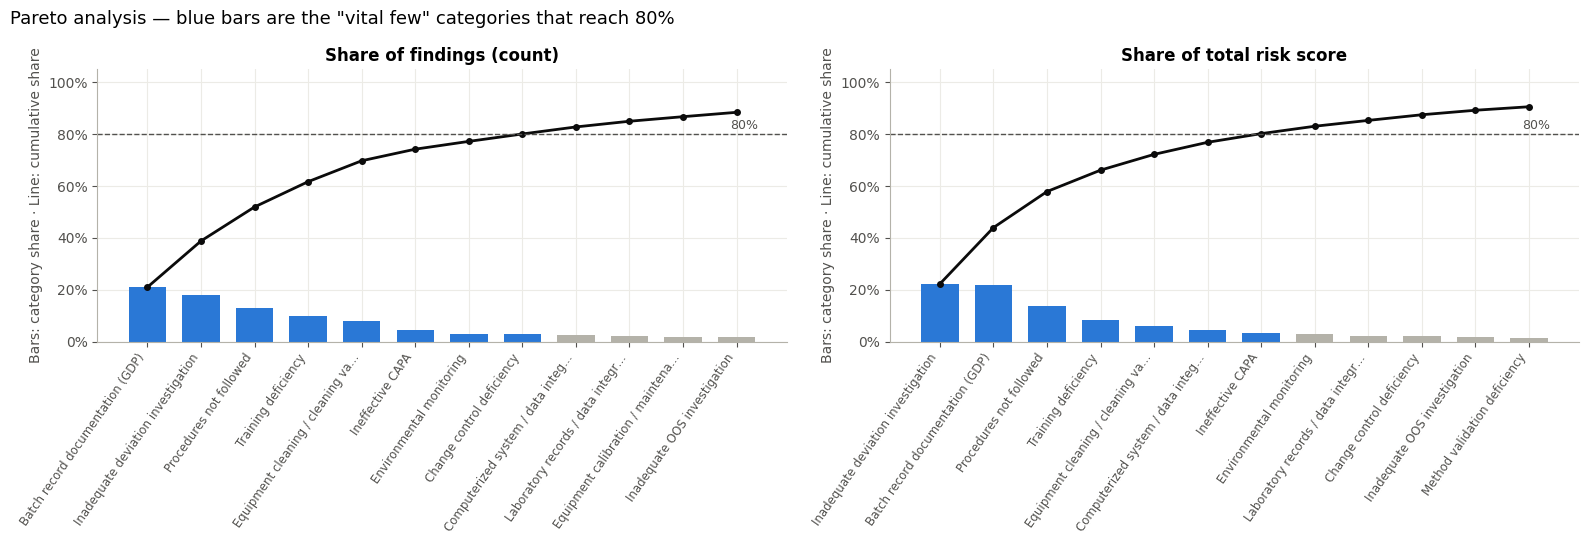

,Rank by count,Rank by risk
1,Batch record documentation (GDP),Inadequate deviation investigation
2,Inadequate deviation investigation,Batch record documentation (GDP)
3,Procedures not followed,Procedures not followed
4,Training deficiency,Training deficiency
5,Equipment cleaning / cleaning validation,Equipment cleaning / cleaning validation
6,Ineffective CAPA,Computerized system / data integrity


In [2]:
def pareto_table(values):
    t = values.sort_values(ascending=False).to_frame('value')
    t['share'] = t['value'] / t['value'].sum()
    t['cumulative'] = t['share'].cumsum()
    return t

by_count = pareto_table(df['category'].value_counts())
by_risk  = pareto_table(df.groupby('category')['risk_score'].sum())

N_SHOW = 12
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, t, title in [(axes[0], by_count, 'Share of findings (count)'),
                     (axes[1], by_risk,  'Share of total risk score')]:
    top = t.head(N_SHOW)
    vital = top['cumulative'].shift(fill_value=0) < 0.8          # the "vital few" that reach 80%
    x = range(len(top))
    # Bars (each category's share) and line (cumulative share) are both percentages, so they share one axis
    ax.bar(x, top['share'] * 100, color=np.where(vital, BLUE, GRAY), width=0.7)
    ax.plot(x, top['cumulative'] * 100, color=INK, lw=2, marker='o', ms=4)
    ax.axhline(80, color=MUTED, lw=1, ls='--')
    ax.text(len(top) - 0.6, 82, '80%', color=MUTED, ha='right', fontsize=9)
    ax.set_xticks(list(x))
    ax.set_xticklabels([c if len(c) <= 34 else c[:32] + '…' for c in top.index], rotation=55, ha='right', fontsize=8.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylim(0, 105)
    ax.set_title(title); ax.set_ylabel('Bars: category share · Line: cumulative share')
fig.suptitle('Pareto analysis — blue bars are the "vital few" categories that reach 80%', x=0.01, ha='left', fontsize=13)
plt.tight_layout(); save(fig, '01_pareto'); plt.show()

rank_compare = pd.DataFrame({'Rank by count': by_count.index[:6], 'Rank by risk': by_risk.index[:6]}, index=range(1, 7))
rank_compare

## 3. Trends

Raw finding counts depend on how many audits happened, so the fair comparison is **findings per audit**.
Each point below is the **trailing 12 months** ending that quarter, which smooths out the noise from individual audits.

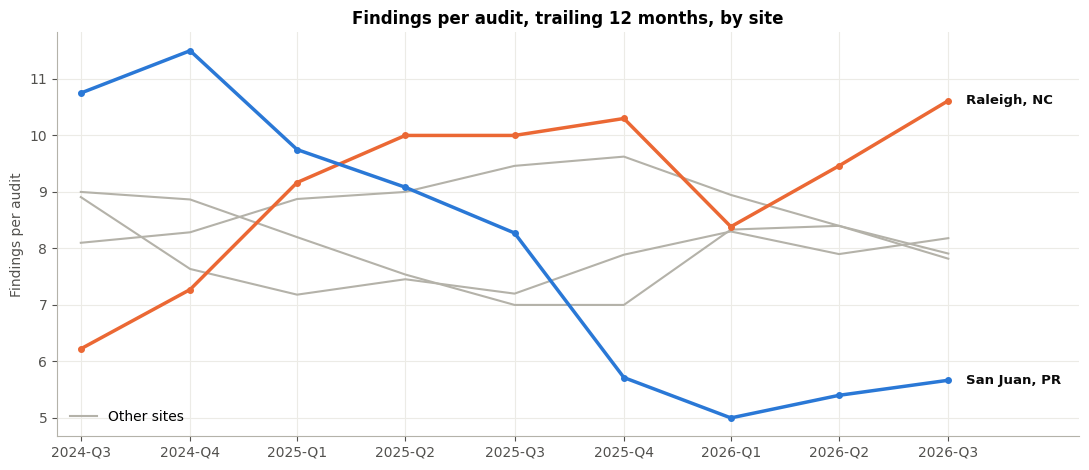

,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1,2026-Q2,2026-Q3
"Basel, Switzerland",8.9,7.6,7.2,7.5,7.2,7.9,8.3,7.9,8.2
"Cork, Ireland",8.1,8.3,8.9,9.0,9.5,9.6,8.9,8.4,7.9
"Hyderabad, India",9.0,8.9,8.2,7.5,7.0,7.0,8.3,8.4,7.8
"Raleigh, NC",6.2,7.3,9.2,10.0,10.0,10.3,8.4,9.5,10.6
"San Juan, PR",10.8,11.5,9.8,9.1,8.3,5.7,5.0,5.4,5.7


In [3]:
quarter_ends = pd.date_range('2024-09-30', SNAPSHOT, freq='QE')

def trailing_fpa(site, end):
    lo = end - pd.Timedelta(days=365)
    f = ((df['site_name'] == site) & (df['audit_date'] > lo) & (df['audit_date'] <= end)).sum()
    a = ((audits['site_name'] == site) & (audits['audit_date'] > lo) & (audits['audit_date'] <= end)).sum()
    return f / a if a else np.nan

fpa = pd.DataFrame({s: [trailing_fpa(s, q) for q in quarter_ends] for s in sorted(df['site_name'].unique())},
                   index=quarter_ends)

# Highlight the two sites with the biggest change; the rest stay gray for context
change = (fpa.iloc[-1] - fpa.iloc[0]).sort_values()
IMPROVER, WORSENER = change.index[0], change.index[-1]

fig, ax = plt.subplots(figsize=(11, 4.8))
for s in fpa.columns:
    highlight = s in (IMPROVER, WORSENER)
    color = ORANGE if s == WORSENER else BLUE if s == IMPROVER else GRAY
    ax.plot(fpa.index, fpa[s], color=color, lw=2.5 if highlight else 1.5, zorder=3 if highlight else 1,
            marker='o' if highlight else None, ms=4)
    if highlight:   # label only the two highlighted sites; the gray lines are context
        ax.text(fpa.index[-1] + pd.Timedelta(days=15), fpa[s].iloc[-1], s, va='center', fontsize=9.5,
                color=INK, fontweight='bold')
ax.plot([], [], color=GRAY, lw=1.5, label='Other sites')
ax.legend(loc='lower left')
ax.set_xticks(fpa.index); ax.set_xticklabels([f'{q.year}-Q{q.quarter}' for q in fpa.index])
ax.set_title('Findings per audit, trailing 12 months, by site')
ax.set_ylabel('Findings per audit'); ax.set_xlim(fpa.index[0] - pd.Timedelta(days=20), fpa.index[-1] + pd.Timedelta(days=110))
plt.tight_layout(); save(fig, '02_trend_findings_per_audit'); plt.show()

fpa.T.round(1).set_axis([f'{q.year}-Q{q.quarter}' for q in fpa.index], axis=1)

### CAPA on-time closure
A CAPA is **on time** if it closed on or before its due date. Grouping by the quarter each CAPA was **due**
(rather than when it closed) is fairer: it counts CAPAs that are still open past their due date as late,
instead of quietly leaving them out.

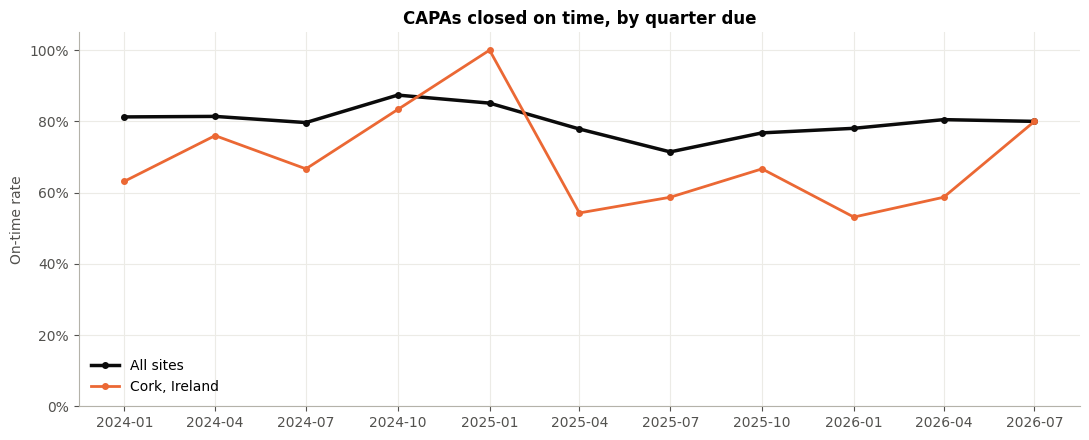

On-time closure rate by site (all CAPAs due by snapshot):
site_name
Cork, Ireland         63%
San Juan, PR          83%
Basel, Switzerland    84%
Raleigh, NC           85%
Hyderabad, India      88%


In [4]:
due = df[df['due_date'] <= SNAPSHOT].copy()
due['on_time'] = (due['status'] == 'Closed') & (due['close_date'] <= due['due_date'])
due['due_q'] = due['due_date'].dt.to_period('Q')

# Skip quarters with too few CAPAs due to give a stable rate (the first quarter of data, mainly)
counts = due.groupby('due_q').size()
keep = counts[counts >= 30].index
network = due.groupby('due_q')['on_time'].mean().loc[keep]
by_site = due.groupby(['due_q', 'site_name'])['on_time'].mean().unstack().loc[keep]
site_overall = due.groupby('site_name')['on_time'].mean().sort_values()
LAGGARD = site_overall.index[0]

fig, ax = plt.subplots(figsize=(11, 4.5))
x = network.index.to_timestamp()
ax.plot(x, network * 100, color=INK, lw=2.5, marker='o', ms=4, label='All sites')
ax.plot(x, by_site[LAGGARD] * 100, color=ORANGE, lw=2, marker='o', ms=4, label=LAGGARD)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylim(0, 105)
ax.set_title('CAPAs closed on time, by quarter due'); ax.set_ylabel('On-time rate')
ax.legend(loc='lower left')
plt.tight_layout(); save(fig, '03_trend_capa_on_time'); plt.show()

print('On-time closure rate by site (all CAPAs due by snapshot):')
print(site_overall.map('{:.0%}'.format).to_string())

### Severity mix over time
The share of findings rated Critical or Major. A falling line means audits are finding less serious problems.

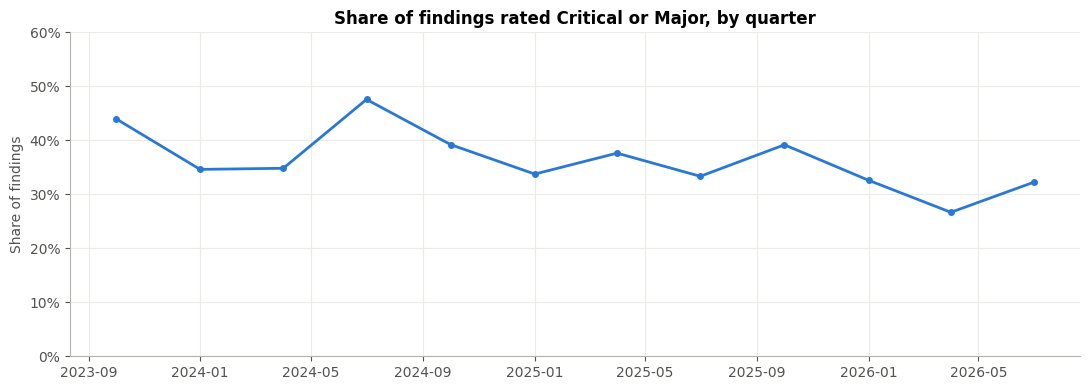

In [5]:
q = df.groupby(df['audit_date'].dt.to_period('Q'))
sev = pd.DataFrame({'crit_major_share': q['severity'].apply(lambda s: s.isin(['Critical', 'Major']).mean()),
                    'findings': q.size()})

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sev.index.to_timestamp(), sev['crit_major_share'] * 100, color=BLUE, lw=2, marker='o', ms=4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylim(0, 60)
ax.set_title('Share of findings rated Critical or Major, by quarter'); ax.set_ylabel('Share of findings')
plt.tight_layout(); save(fig, '04_trend_severity'); plt.show()

## 4. Recurrence
A repeat is the same problem on the same item at the same site within two years (rule 5.4).
The key question for leadership: **does a CAPA that fails its effectiveness check predict a repeat?**
If yes, failed effectiveness checks are an early warning worth acting on.

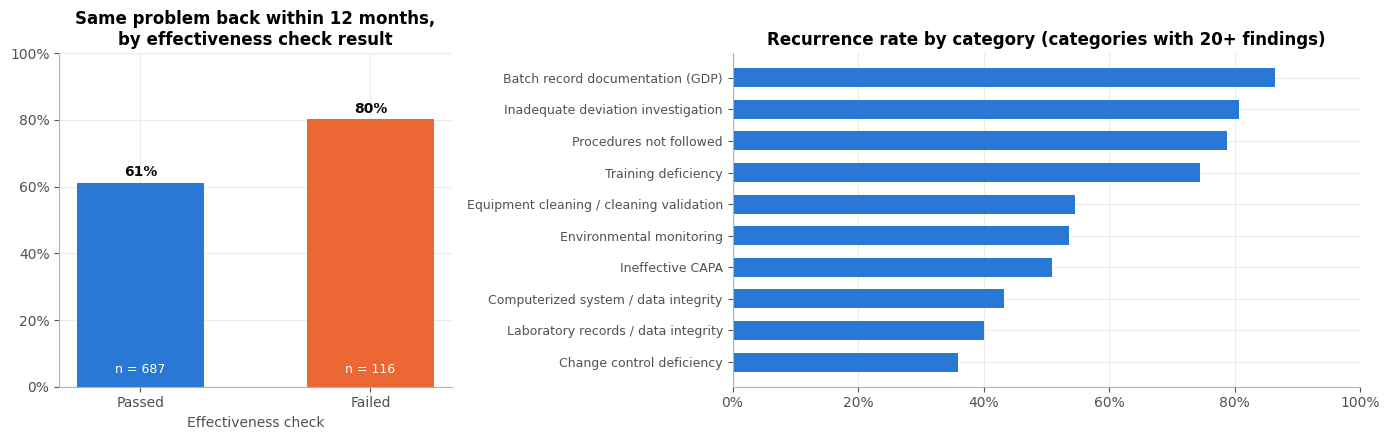

,site_name,category,affected_item,times cited
0,"Hyderabad, India",Batch record documentation (GDP),MRD-562,27
1,"San Juan, PR",Batch record documentation (GDP),MRD-263,25
2,"Cork, Ireland",Batch record documentation (GDP),MRD-352 API,25
3,"Raleigh, NC",Inadequate deviation investigation,MRD-104,22
4,"Basel, Switzerland",Inadequate deviation investigation,MRD-452,21
5,"Cork, Ireland",Batch record documentation (GDP),MRD-368 API,21
6,"Raleigh, NC",Batch record documentation (GDP),MRD-166,19
7,"Basel, Switzerland",Batch record documentation (GDP),MRD-495,17
8,"Hyderabad, India",Procedures not followed,Microbiology,17
9,"Basel, Switzerland",Procedures not followed,Manufacturing,16


In [6]:
# For each closed CAPA (closed at least 12 months before snapshot, so there is a full year to observe),
# did the same problem on the same item come back within 12 months of closure?
dates = df.groupby(['site_id', 'category', 'affected_item'])['audit_date'].apply(np.sort).to_dict()
obs = df[closed & (df['close_date'] <= SNAPSHOT - pd.Timedelta(days=365))].copy()
obs['came_back'] = [((d > r.close_date) & (d <= r.close_date + pd.Timedelta(days=365))).any()
                    for r in obs.itertuples() for d in [dates[(r.site_id, r.category, r.affected_item)]]]
repeat_after = obs.groupby('effectiveness_check')['came_back'].agg(['mean', 'size'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 1.6]})
ax = axes[0]
vals = repeat_after.reindex(['Pass', 'Fail'])
ax.bar(['Passed', 'Failed'], vals['mean'] * 100, color=[BLUE, ORANGE], width=0.55)
for i, (m, n) in enumerate(zip(vals['mean'], vals['size'])):
    ax.text(i, m * 100 + 2, f'{m:.0%}', ha='center', fontweight='bold', color=INK)
    ax.text(i, 4, f'n = {n}', ha='center', color='white', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylim(0, 100)
ax.set_title('Same problem back within 12 months,\nby effectiveness check result'); ax.set_xlabel('Effectiveness check')

ax = axes[1]
rec_cat = df.groupby('category')['is_recurrent'].agg(['mean', 'size'])
rec_cat = rec_cat[rec_cat['size'] >= 20].sort_values('mean').tail(10)
ax.barh(rec_cat.index, rec_cat['mean'] * 100, color=BLUE, height=0.6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_xlim(0, 100)
ax.set_title('Recurrence rate by category (categories with 20+ findings)'); ax.tick_params(axis='y', labelsize=9)
plt.tight_layout(); save(fig, '05_recurrence'); plt.show()

# The chronic offenders: same problem on the same item, cited most often
chronic = (df.groupby(['site_name', 'category', 'affected_item']).size()
             .sort_values(ascending=False).head(10).rename('times cited').reset_index())
chronic

## 5. Site profile
One row per site, comparing the measures that matter for inspection readiness.
The "vs. others" column is how many times worse (or better) the worst site is than the average of the rest.

In [7]:
DI = df['category'].str.contains('data integrity', case=False)
profile = pd.DataFrame({
    'Findings per audit':       df.groupby('site_name').size() / audits.groupby('site_name').size(),
    'Critical+Major share':     df.groupby('site_name')['severity'].apply(lambda s: s.isin(['Critical', 'Major']).mean()),
    'Data integrity share':     DI.groupby(df['site_name']).mean(),
    'Median days to close':     df[closed].groupby('site_name')['days_open'].median(),
    'On-time closure':          site_overall,
    'Failed effectiveness checks': df[closed].groupby('site_name')['effectiveness_check'].apply(lambda s: (s == 'Fail').mean()),
    'Recurrence rate':          df.groupby('site_name')['is_recurrent'].mean(),
    'Needs attention (Med+High)': df.groupby('site_name')['risk_tier'].apply(lambda s: (s != 'Low').sum()),
})

# Which site stands out most? Count how often each site is the worst on each measure.
worse_is_higher = {'Findings per audit': True, 'Critical+Major share': True, 'Data integrity share': True,
                   'Median days to close': True, 'On-time closure': False, 'Failed effectiveness checks': True,
                   'Recurrence rate': True, 'Needs attention (Med+High)': True}
worst = {m: (profile[m].idxmax() if hi else profile[m].idxmin()) for m, hi in worse_is_higher.items()}
FOCUS_SITE = pd.Series(worst).value_counts().index[0]
print(f'Site that is worst on the most measures: {FOCUS_SITE} '
      f'({pd.Series(worst).value_counts().iloc[0]} of {len(worst)})')

pct_cols = ['Critical+Major share', 'Data integrity share', 'On-time closure', 'Failed effectiveness checks', 'Recurrence rate']
show = profile.copy()
for c in pct_cols: show[c] = show[c].map('{:.0%}'.format)
show['Findings per audit'] = show['Findings per audit'].round(1)
show['Median days to close'] = show['Median days to close'].round(0).astype(int)
show

Site that is worst on the most measures: Cork, Ireland (6 of 8)


,Findings per audit,Critical+Major share,Data integrity share,Median days to close,On-time closure,Failed effectiveness checks,Recurrence rate,Needs attention (Med+High)
site_name,,,,,,,,
"Basel, Switzerland",8.1,33%,4%,53,84%,14%,60%,35
"Cork, Ireland",8.6,37%,11%,70,63%,27%,69%,51
"Hyderabad, India",8.0,38%,1%,53,88%,13%,65%,25
"Raleigh, NC",9.2,33%,5%,53,85%,13%,64%,32
"San Juan, PR",7.9,40%,2%,49,83%,10%,65%,17


## 6. CAPA aging
How long have the still-open CAPAs been open? Old open CAPAs are a common inspection observation on their own.

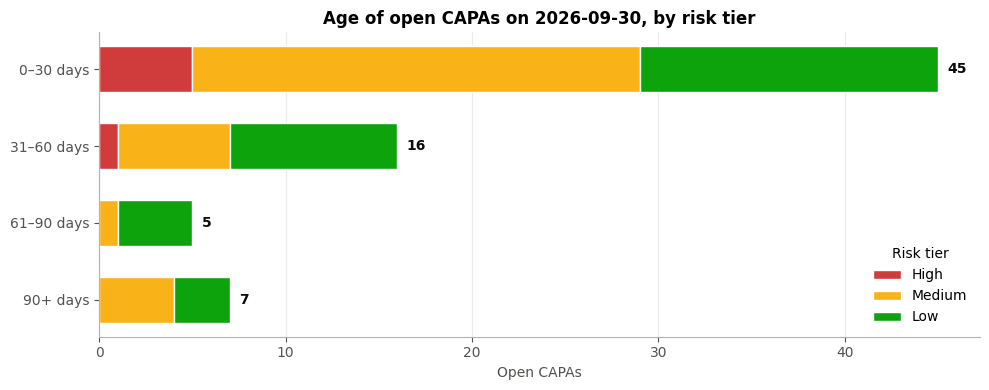

Open CAPAs older than 90 days:


,finding_id,site_name,category,severity,status,age_days,risk_tier
973,F00974,"Cork, Ireland",Batch record documentation (GDP),Minor,Effectiveness Check Pending,322,Medium
1026,F01027,"Raleigh, NC",Equipment calibration / maintenance,Minor,Effectiveness Check Pending,259,Low
1018,F01019,"Raleigh, NC",Training deficiency,Minor,Effectiveness Check Pending,258,Medium
1172,F01173,"Raleigh, NC",Batch record documentation (GDP),Minor,In Progress,186,Medium
1212,F01213,"Basel, Switzerland",Label control / reconciliation,Minor,Effectiveness Check Pending,152,Low
1242,F01243,"Raleigh, NC",Annual product review incomplete,Minor,Effectiveness Check Pending,115,Low
1255,F01256,"San Juan, PR",Procedures not followed,Minor,Effectiveness Check Pending,98,Medium


In [8]:
op = df[active].copy()
op['age_days'] = (SNAPSHOT - op['open_date']).dt.days
BUCKETS = ['0–30 days', '31–60 days', '61–90 days', '90+ days']
op['age_bucket'] = pd.cut(op['age_days'], [-1, 30, 60, 90, 10_000], labels=BUCKETS)
aging = pd.crosstab(op['age_bucket'], op['risk_tier']).reindex(index=BUCKETS, columns=['High', 'Medium', 'Low'], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
left = np.zeros(len(aging))
for t in ['High', 'Medium', 'Low']:
    ax.barh(aging.index, aging[t], left=left, color=TIER_COLORS[t], label=t, height=0.6, edgecolor='white', linewidth=1)
    left += aging[t].to_numpy()
for i, total in enumerate(left):
    ax.text(total + 0.5, i, f'{int(total)}', va='center', color=INK, fontweight='bold')
ax.invert_yaxis(); ax.set_xlabel('Open CAPAs'); ax.grid(axis='y', visible=False)
ax.set_title(f'Age of open CAPAs on {SNAPSHOT.date()}, by risk tier')
ax.legend(title='Risk tier', loc='lower right')
plt.tight_layout(); save(fig, '06_capa_aging'); plt.show()

print('Open CAPAs older than 90 days:')
op[op['age_days'] > 90][['finding_id', 'site_name', 'category', 'severity', 'status', 'age_days', 'risk_tier']] \
    .sort_values('age_days', ascending=False)

## 7. Key insights
Generated from the results above. Copy these into your README and use them as annotations on the dashboard.

In [9]:
others = profile.drop(FOCUS_SITE)
top5_share = by_count['share'].head(5).sum()
first_fpa, last_fpa = fpa.iloc[0], fpa.iloc[-1]
fail_rate, pass_rate = repeat_after.loc['Fail', 'mean'], repeat_after.loc['Pass', 'mean']
net_first = due[due['due_date'] < START + pd.Timedelta(days=365 + 90)]['on_time'].mean()
net_last  = due[due['due_date'] > SNAPSHOT - pd.Timedelta(days=365)]['on_time'].mean()
high_active = df[active & (df['risk_tier'] == 'High')]
risk_rank_note = ('the same top category' if by_count.index[0] == by_risk.index[0] else
                  f'**{by_risk.index[0]}** moves to #1 (it is #{list(by_count.index).index(by_risk.index[0]) + 1} by count) '
                  f'because more of its findings are severe or unresolved')

insights = [
    f"**A few problems drive most findings.** The top 5 of {df['category'].nunique()} categories account for "
    f"{top5_share:.0%} of all findings, led by {by_count.index[0]}. Ranked by risk instead of count, {risk_rank_note}.",

    f"**{WORSENER} is getting worse.** Findings per audit rose from {first_fpa[WORSENER]:.1f} to {last_fpa[WORSENER]:.1f} "
    f"(trailing 12 months), the largest increase in the network.",

    f"**{IMPROVER} is improving.** Findings per audit fell from {first_fpa[IMPROVER]:.1f} to {last_fpa[IMPROVER]:.1f}, "
    f"consistent with a remediation program taking effect.",

    f"**{FOCUS_SITE} needs the most attention.** Data integrity makes up {profile.loc[FOCUS_SITE, 'Data integrity share']:.0%} "
    f"of its findings vs {others['Data integrity share'].mean():.0%} at other sites; its CAPAs take a median "
    f"{profile.loc[FOCUS_SITE, 'Median days to close']:.0f} days to close (others: {others['Median days to close'].mean():.0f}) "
    f"and {profile.loc[FOCUS_SITE, 'Failed effectiveness checks']:.0%} fail their effectiveness check "
    f"(others: {others['Failed effectiveness checks'].mean():.0%}).",

    f"**Failed effectiveness checks predict repeats.** When a CAPA failed its check, the same problem came back within "
    f"12 months {fail_rate:.0%} of the time, vs {pass_rate:.0%} when it passed. A failed check is an early warning.",

    (f"**On-time CAPA closure is {'slipping' if net_last < net_first else 'improving'}.** {net_first:.0%} of CAPAs due "
     f"in the first year closed on time, vs {net_last:.0%} of those due in the last 12 months."
     if abs(net_last - net_first) >= 0.05 else
     f"**On-time CAPA closure is steady at about {due['on_time'].mean():.0%} across the network**, "
     f"but {LAGGARD} lags at {site_overall[LAGGARD]:.0%}, the lowest of any site."),

    f"**{active.sum()} CAPAs are open, {(op['age_days'] > 90).sum()} of them for more than 90 days.** "
    f"{len(high_active)} open findings are High risk, at "
    f"{', '.join(f'{s} ({n})' for s, n in high_active['site_name'].value_counts().items())}.",
]

text = '\n'.join(f'{i}. {s}' for i, s in enumerate(insights, 1))
from IPython.display import Markdown, display
display(Markdown(text))

with open(f'{PROJECT}/data/processed/key_insights.md', 'w') as f:
    f.write('# Key insights\n\n' + text + '\n')
print(f'\nSaved → {PROJECT}/data/processed/key_insights.md')
print(f'Charts saved → {FIG_DIR}/ :', sorted(os.listdir(FIG_DIR)))

1. **A few problems drive most findings.** The top 5 of 24 categories account for 70% of all findings, led by Batch record documentation (GDP). Ranked by risk instead of count, **Inadequate deviation investigation** moves to #1 (it is #2 by count) because more of its findings are severe or unresolved.
2. **Raleigh, NC is getting worse.** Findings per audit rose from 6.2 to 10.6 (trailing 12 months), the largest increase in the network.
3. **San Juan, PR is improving.** Findings per audit fell from 10.8 to 5.7, consistent with a remediation program taking effect.
4. **Cork, Ireland needs the most attention.** Data integrity makes up 11% of its findings vs 3% at other sites; its CAPAs take a median 70 days to close (others: 52) and 27% fail their effectiveness check (others: 12%).
5. **Failed effectiveness checks predict repeats.** When a CAPA failed its check, the same problem came back within 12 months 80% of the time, vs 61% when it passed. A failed check is an early warning.
6. **On-time CAPA closure is steady at about 80% across the network**, but Cork, Ireland lags at 63%, the lowest of any site.
7. **73 CAPAs are open, 7 of them for more than 90 days.** 6 open findings are High risk, at Basel, Switzerland (4), Hyderabad, India (1), Raleigh, NC (1).


Saved → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/processed/key_insights.md
Charts saved → /content/drive/MyDrive/gmp-audit-risk-dashboard/figures/ : ['01_pareto.png', '02_trend_findings_per_audit.png', '03_trend_capa_on_time.png', '04_trend_severity.png', '05_recurrence.png', '06_capa_aging.png']


## Next steps
1. Read the insights in Section 7 and check each one against its chart. You should be able to explain every number in an interview.
2. Download the charts from `figures/` in Drive (you'll add them to the README in Phase 8).
3. **File → Save a copy in GitHub** → `notebooks/03_analysis.ipynb`.
4. Move on to Phase 5: building the dashboard from `findings_scored.csv`.